# L=32 sweep: CPMC with a χ_T=8 DMRG trial, walker bond χ_w = 2, 4, 6

Runs from `run_mps_sweep.py` (`mps_cpmc_new.py` with the canonical-centre fix, adaptive plan, 200 walkers, 60 equilibration + 200 sampling blocks of 20 steps, Δτ = 0.01, U = 4, half filling). Data: `sweep_L32_T8/results.jsonl` (final blocking analysis), `sweep_L32_T8/blocks.jsonl` (every block, before trot's outlier rejection), and the run logs. Reference: DMRG at χ=200 from `study_dmrg_ref.jsonl`.

In [5]:
import json
import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from trot.stat_utils import reject_outliers

RUN = Path("sweep_L32_T8")
CHI_W = (2, 4, 6)
COLOR = {2: "#2a78d6", 4: "#eb6834", 6: "#1baf7a"}          # categorical slots 1-3, fixed per chi_w
INK, INK2, GRID, SURFACE = "#0b0b0b", "#52514e", "#e6e5e1", "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.linewidth": 1.0, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 11, "axes.labelsize": 10, "xtick.color": INK2, "ytick.color": INK2,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 1.0, "grid.linestyle": "-",
    "axes.spines.top": False, "axes.spines.right": False, "lines.linewidth": 2.0,
    "lines.solid_capstyle": "round", "legend.frameon": False, "font.size": 10,
})

results = {json.loads(l)["walker_channel_chi"]: json.loads(l) for l in open(RUN / "results.jsonl")}
blocks = {w: [] for w in CHI_W}
for line in open(RUN / "blocks.jsonl"):
    r = json.loads(line)
    blocks[int(re.search(r"_w(\d+)_", r["tag"]).group(1))].append(r)
discarded = {}
for w in CHI_W:
    text = (RUN / f"L32_T8_w{w}_s1234.log").read_text()
    discarded[w] = float(re.search(r"discarded weights: ([0-9.e+-]+)", text).group(1))
E_ref = next(json.loads(l)["e_dmrg_chi200"] for l in open("study_dmrg_ref.jsonl") if json.loads(l)["L"] == 32)
E_trial = results[2]["trial_energy"]
n_eql = results[2]["n_equilibration"]

print(f"{'chi_w':>5} {'d=4 bond':>8} {'discarded/channel':>18} {'E_CPMC':>12} {'error':>8} {'E - E_ref':>10} {'nodes':>8}")
for w in CHI_W:
    r = results[w]
    print(f"{w:>5} {r['walker_d4_chi']:>8} {discarded[w]:18.2e} {r['cpmc_energy']:12.5f} {r['cpmc_error']:8.5f} "
          f"{r['cpmc_energy'] - E_ref:10.5f} {blocks[w][-1]['node_encounters']:>8}")
print(f"DMRG chi=200 reference {E_ref:.5f};  trial (chi_T=8) {E_trial:.5f}")

chi_w d=4 bond  discarded/channel       E_CPMC    error  E - E_ref    nodes
    2        4           7.59e-01    -17.92491  0.00507    0.06967    36475
    4       16           1.32e-01    -17.95418  0.00160    0.04040      417
    6       36           6.28e-03    -17.96806  0.00198    0.02652        0
DMRG chi=200 reference -17.99458;  trial (chi_T=8) -17.84894


## Energy against walker bond dimension

One point per run, with the error bar from trot's blocking analysis. The dashed line is the trial energy alone (χ_T = 8). The energy is still moving between χ_w = 4 and 6, so walker truncation is not converged at χ_w = 6. The second and third plots show why χ_w = 2 is so far off: it throws away 76% of the norm of each channel on the reference determinant, and the constraint then removes walkers far more often.

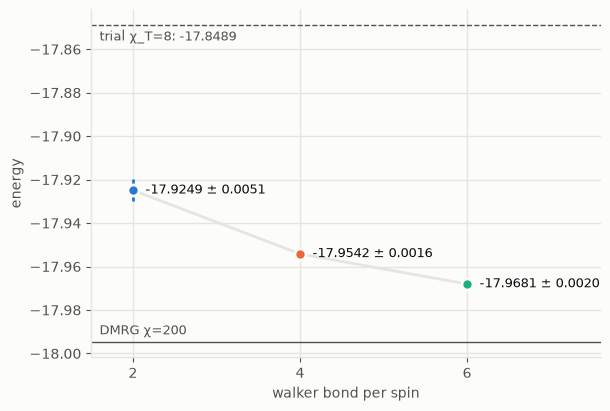

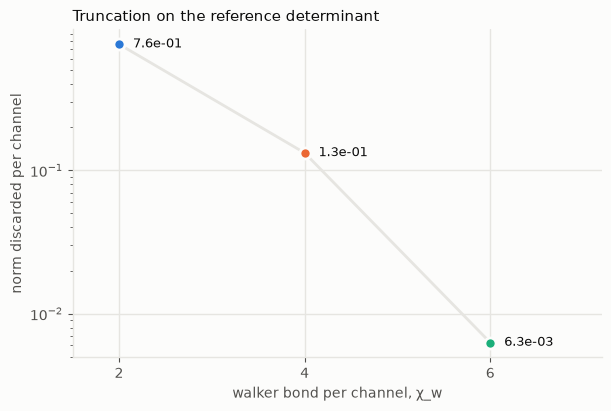

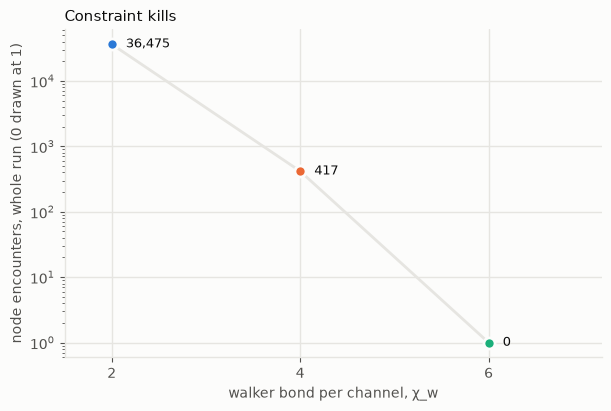

In [7]:
x = np.array(CHI_W)

fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
E = np.array([results[w]["cpmc_energy"] for w in CHI_W])
err = np.array([results[w]["cpmc_error"] for w in CHI_W])
ax.axhline(E_ref, color=INK2, lw=1)
ax.text(1.6, E_ref + 0.002, "DMRG χ=200", color=INK2, va="bottom", fontsize=9)
ax.axhline(E_trial, color=INK2, lw=1, ls="--")
ax.text(1.6, E_trial - 0.002, f"trial χ_T=8: {E_trial:.4f}", color=INK2, va="top", fontsize=9)
ax.plot(x, E, color=GRID, lw=2, zorder=1)
for w, e, s in zip(CHI_W, E, err):
    ax.errorbar(w, e, yerr=s, fmt="o", ms=8, color=COLOR[w], mec=SURFACE, mew=2, elinewidth=2, capsize=0, zorder=3)
    ax.text(w + 0.15, e, f"{e:.4f} ± {s:.4f}", color=INK, va="center", fontsize=9)
ax.set_xlim(1.5, 7.6)
ax.set_xticks(x)
ax.set_xlabel("walker bond per spin")
ax.set_ylabel("energy")
# ax.set_title("E_CPMC", loc="left")
plt.show()

fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
d = np.array([discarded[w] for w in CHI_W])
ax.plot(x, d, color=GRID, lw=2, zorder=1)
for w, v in zip(CHI_W, d):
    ax.plot(w, v, "o", ms=8, color=COLOR[w], mec=SURFACE, mew=2, zorder=3)
    ax.text(w + 0.15, v, f"{v:.1e}", color=INK, va="center", fontsize=9)
ax.set_yscale("log")
ax.set_xlim(1.5, 7.2)
ax.set_xticks(x)
ax.set_xlabel("walker bond per channel, χ_w")
ax.set_ylabel("norm discarded per channel")
ax.set_title("Truncation on the reference determinant", loc="left")
plt.show()

fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
nodes = np.array([blocks[w][-1]["node_encounters"] for w in CHI_W])
shown = np.maximum(nodes, 1)
ax.plot(x, shown, color=GRID, lw=2, zorder=1)
for w, n, v in zip(CHI_W, nodes, shown):
    ax.plot(w, v, "o", ms=8, color=COLOR[w], mec=SURFACE, mew=2, zorder=3)
    ax.text(w + 0.15, v, f"{n:,}", color=INK, va="center", fontsize=9)
ax.set_yscale("log")
ax.set_xlim(1.5, 7.2)
ax.set_xticks(x)
ax.set_xlabel("walker bond per channel, χ_w")
ax.set_ylabel("node encounters, whole run (0 drawn at 1)")
ax.set_title("Constraint kills", loc="left")
plt.show()

## Block energies through the run

Each panel is one run: the thin line is the energy of every block, the thick line the running weighted mean over the sampling blocks that trot's outlier filter keeps (so it ends at the reported value), and the shaded band the equilibration phase. The y-range is the same in all three panels. χ_w = 2 has two blocks above it, marked: block 237, which trot's filter rejected, and block 137, which it kept. Both are single walkers with tiny truncated overlaps blowing up the local energy.

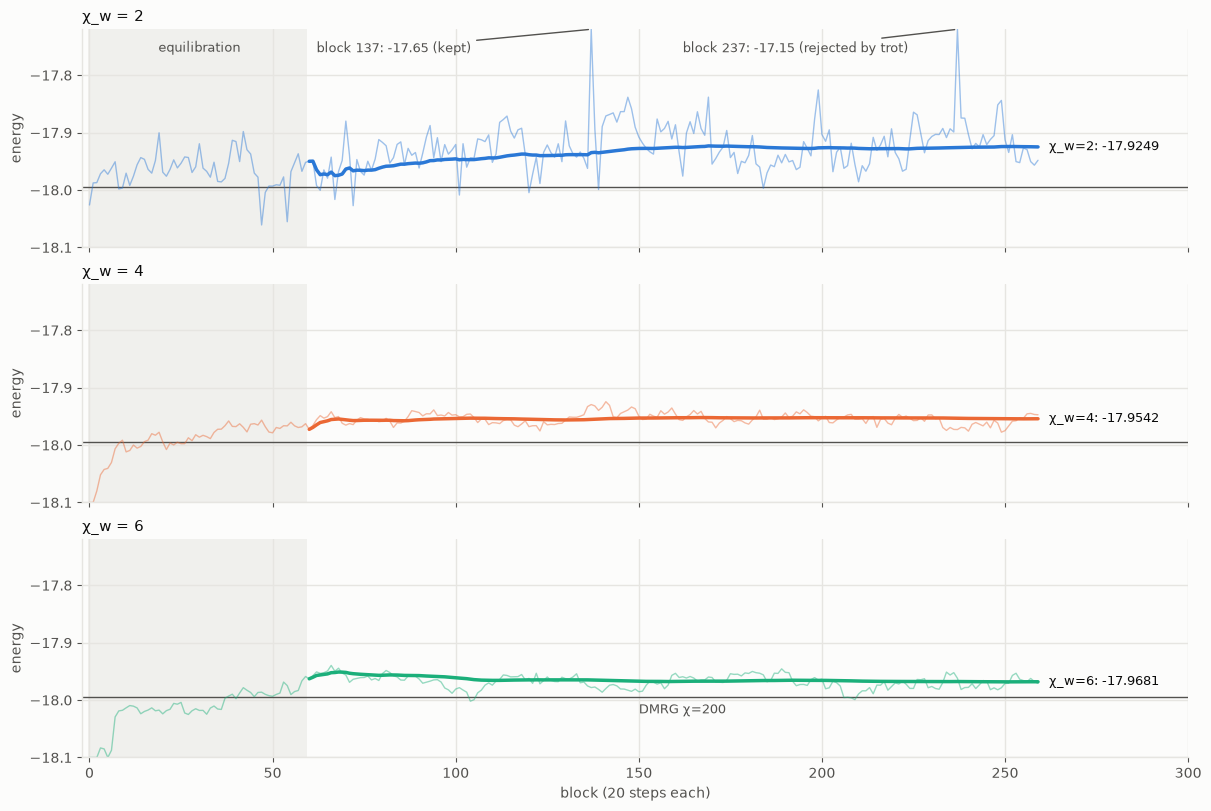

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True, sharey=True, constrained_layout=True)
ylo, yhi = -18.10, -17.72
for ax, w in zip(axes, CHI_W):
    rs = blocks[w]
    b = np.array([r["block"] for r in rs])
    e = np.array([r["energy"] for r in rs])
    wt = np.array([r["weight"] for r in rs])
    s = b >= n_eql
    _, keep = reject_outliers(np.column_stack((e[s], wt[s])), obs=0)
    keep = np.asarray(keep)
    rejected = set(b[s][~keep].tolist())
    bs, es, ws = b[s][keep], e[s][keep], wt[s][keep]
    running = np.cumsum(es * ws) / np.cumsum(ws)
    ax.axvspan(-0.5, n_eql - 0.5, color=GRID, alpha=0.5, lw=0)
    ax.axhline(E_ref, color=INK2, lw=1)
    ax.plot(b, np.clip(e, ylo, yhi), color=COLOR[w], lw=1, alpha=0.45)
    ax.plot(bs, running, color=COLOR[w], lw=2.5)
    ax.text(b[-1] + 3, running[-1], f"χ_w={w}: {running[-1]:.4f}", color=INK, va="center", fontsize=9)
    for bi, ei in zip(b, e):
        if ei > yhi:
            status = "rejected by trot" if bi in rejected else "kept"
            ax.annotate(f"block {bi}: {ei:.2f} ({status})", xy=(bi, yhi), xytext=(bi - 75, yhi - 0.04),
                        color=INK2, fontsize=9, arrowprops=dict(arrowstyle="-", color=INK2, lw=1))
    ax.set_ylabel("energy")
    ax.set_title(f"χ_w = {w}", loc="left")
axes[0].text(n_eql / 2, yhi - 0.02, "equilibration", color=INK2, ha="center", va="top", fontsize=9)
axes[-1].text(150, E_ref - 0.012, "DMRG χ=200", color=INK2, va="top", fontsize=9)
axes[-1].set_xlabel("block (20 steps each)")
axes[0].set_ylim(ylo, yhi)
axes[0].set_xlim(-2, 300)
plt.show()

## Population health

Total walker weight per block (left) and cumulative node encounters (right, log scale). With χ_w = 2 the weight drifts and dips, and the constraint fires about 140 times per block; with χ_w = 6 it never fires.

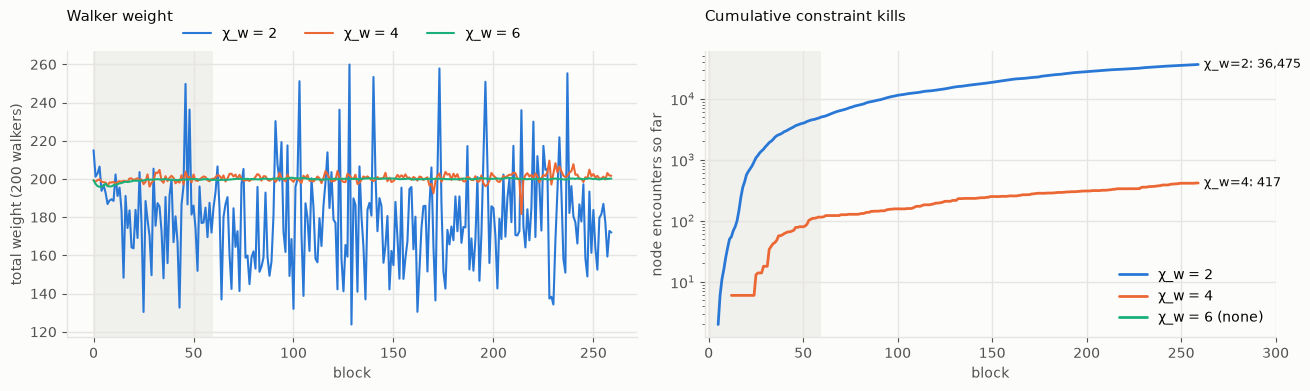

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), constrained_layout=True)
for w in CHI_W:
    rs = blocks[w]
    b = np.array([r["block"] for r in rs])
    axes[0].plot(b, [r["weight"] for r in rs], color=COLOR[w], lw=1.5, label=f"χ_w = {w}")
    n = np.array([r["node_encounters"] for r in rs], float)
    if n[-1] > 0:
        axes[1].plot(b, np.where(n > 0, n, np.nan), color=COLOR[w], lw=2, label=f"χ_w = {w}")
        axes[1].text(b[-1] + 3, n[-1], f"χ_w={w}: {int(n[-1]):,}", color=INK, va="center", fontsize=9)
    else:
        axes[1].plot([], [], color=COLOR[w], lw=2, label=f"χ_w = {w} (none)")
for ax in axes:
    ax.axvspan(-0.5, n_eql - 0.5, color=GRID, alpha=0.5, lw=0)
    ax.set_xlabel("block")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.13), ncol=3) if ax is axes[0] else ax.legend(loc="lower right")
axes[0].set_ylabel("total weight (200 walkers)")
axes[0].set_title("Walker weight", loc="left", pad=22)
axes[1].set_yscale("log")
axes[1].set_xlim(-2, 300)
axes[1].set_ylabel("node encounters so far")
axes[1].set_title("Cumulative constraint kills", loc="left", pad=22)
plt.show()